In [18]:
# ================================
# CORE IMPORTS
# ================================
import xarray as xr
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Optional (performance)
import dask

In [2]:
import os
import xarray as xr

file_path = r"C:\Users\Owner\water_proj\GRACE_FILE.nc"

# Verify file exists
print("File exists:", os.path.exists(file_path))

# Load dataset
ds = xr.open_dataset(file_path, chunks={})

print("\n ✅ Dataset opened successfully")


File exists: True

 ✅ Dataset opened successfully


In [3]:


print("Variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
print("Dimensions:", ds.dims)

Variables: ['lwe_thickness', 'uncertainty', 'lat_bounds', 'lon_bounds', 'time_bounds', 'land_mask', 'scale_factor', 'mascon_ID', 'GAD']
Coordinates: ['lon', 'lat', 'time']
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 253, 'lat': 360, 'lon': 720, 'bounds': 2})


In [4]:

grace = ds["lwe_thickness"]

print("Shape:", grace.shape)
print("Dims:", grace.dims)

Shape: (253, 360, 720)
Dims: ('time', 'lat', 'lon')


In [5]:


print("Min:", float(grace.min().compute()))
print("Max:", float(grace.max().compute()))
print("Mean:", float(grace.mean().compute()))

Min: -2217.592829916833
Max: 1188.0687322767658
Mean: -0.9309341969539481


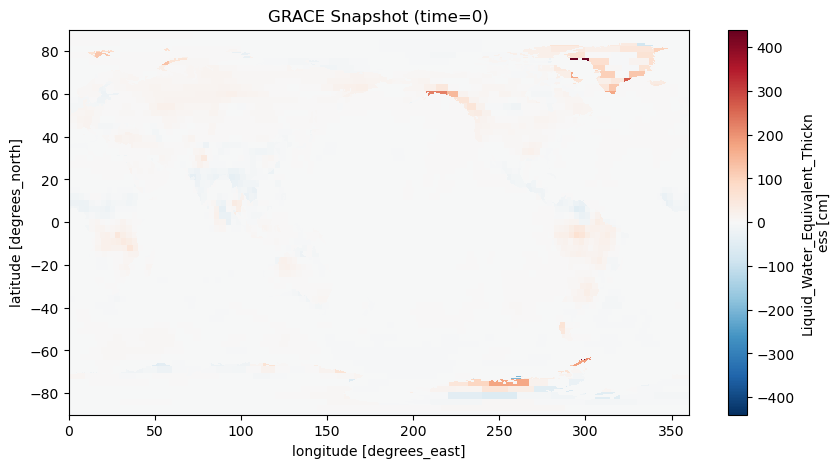

In [6]:


grace.isel(time=0).plot(figsize=(10,5))
plt.title("GRACE Snapshot (time=0)")
plt.show()

In [7]:


grace = grace.clip(min=-100, max=100)

print("✅ GRACE cleaned")
print("New min:", float(grace.min().compute()))
print("New max:", float(grace.max().compute()))

✅ GRACE cleaned
New min: -100.0
New max: 100.0


In [8]:


grace = grace.assign_coords(
    lon=((grace.lon + 180) % 360) - 180
).sortby("lon")

print("✅ Longitude fixed")
print("Lon range:", float(grace.lon.min()), "to", float(grace.lon.max()))

✅ Longitude fixed
Lon range: -179.75 to 179.75


In [9]:
# --- FINAL REGION EXTRACTION (CORRECT FOR -180 → 180 GRID) ---

regions = {
    "california": {"lat": (32, 42), "lon": (-124, -114)},
    "michigan": {"lat": (41, 48), "lon": (-90, -82)}
}

region_data = []

for name, bounds in regions.items():
    subset = grace.sel(
        lat=slice(bounds["lat"][0], bounds["lat"][1]),
        lon=slice(bounds["lon"][0], bounds["lon"][1])
    )
    
    print(f"{name} shape:", subset.shape)
    region_data.append(subset)

# Safe concat (handles slight grid mismatch)
grace_region = xr.concat(region_data, dim="region", join="outer")

print("\n✅ Region extraction complete")
print("Final shape:", grace_region.shape)

california shape: (253, 20, 20)
michigan shape: (253, 14, 16)

✅ Region extraction complete
Final shape: (2, 253, 32, 36)


In [10]:
# --- CLEAN DATA (CRITICAL) ---

import numpy as np

# Replace NaNs with 0 (safe baseline)
grace_region = grace_region.fillna(0)

# Optional: clip extreme values (stabilizes training)
grace_region = grace_region.clip(min=-500, max=500)

print("✅ Data cleaned")

✅ Data cleaned


In [11]:
# --- NORMALIZATION (Z-score) ---

mean = grace_region.mean().compute()
std = grace_region.std().compute()

grace_norm = (grace_region - mean) / std

print("✅ Data normalized")

✅ Data normalized


In [12]:
# --- CREATE SEQUENCES ---

sequence_length = 6

X = []
y = []

data_np = grace_norm.values  # shape: (region, time, lat, lon)

for r in range(data_np.shape[0]):
    for t in range(data_np.shape[1] - sequence_length):
        X.append(data_np[r, t:t+sequence_length])
        y.append(data_np[r, t+sequence_length])

X = np.array(X)
y = np.array(y)

# Add channel dimension
X = X[..., np.newaxis]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (494, 6, 32, 36, 1)
y shape: (494, 32, 36)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (395, 6, 32, 36, 1)
Test: (99, 6, 32, 36, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

# Better input definition (fix warning)
model.add(layers.Input(shape=(sequence_length, X.shape[2], X.shape[3], 1)))

# CNN (spatial)
model.add(layers.TimeDistributed(
    layers.Conv2D(16, (3,3), activation='relu', padding='same')
))
model.add(layers.TimeDistributed(
    layers.MaxPooling2D((2,2))
))
model.add(layers.TimeDistributed(
    layers.Flatten()
))

# LSTM (temporal)
model.add(layers.LSTM(64))

# Output
model.add(layers.Dense(X.shape[2] * X.shape[3]))
model.add(layers.Reshape((X.shape[2], X.shape[3])))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 6, 32, 36, 16)       │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 6, 16, 18, 16)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 6, 4608)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │       1,196,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1152)                │          74,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 32, 36)              │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,271,328 (4.85 MB)

 Trainable params: 1,271,328 (4.85 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=8
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.6920 - mae: 0.3381 - val_loss: 0.5310 - val_mae: 0.2856
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3108 - mae: 0.2378 - val_loss: 0.2994 - val_mae: 0.2378
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1847 - mae: 0.1945 - val_loss: 0.1959 - val_mae: 0.1944
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1364 - mae: 0.1692 - val_loss: 0.1911 - val_mae: 0.1907
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1245 - mae: 0.1618 - val_loss: 0.1361 - val_mae: 0.1702
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1005 - mae: 0.1487 - val_loss: 0.1324 - val_mae: 0.1628
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0891 - mae: 0.1380 - val_loss: 0.1062 - val_mae: 0.1492
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0810 - mae: 0.1309 - val_loss: 0.1012 - val_mae: 0.1416
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.079

In [16]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0714 - mae: 0.1174
Test Loss: 0.07136408984661102
Test MAE: 0.11736173182725906


In [17]:
# ✅ FINAL SAVE (PROPER / MODERN)
model.save("groundwater_model.keras")

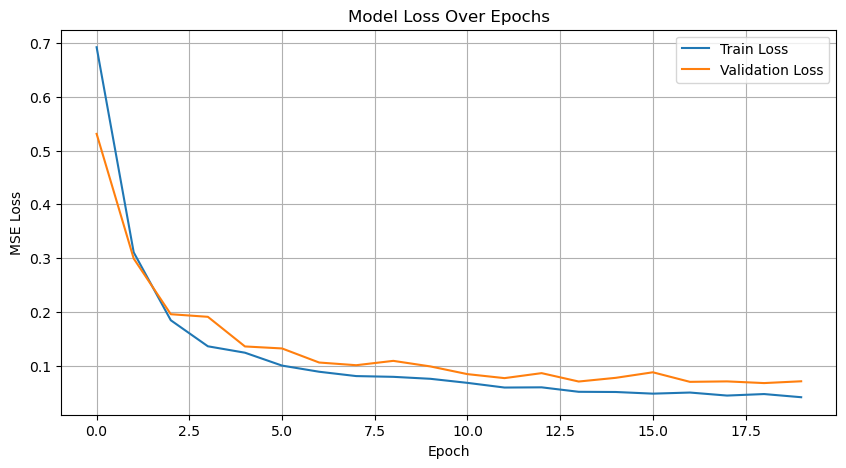

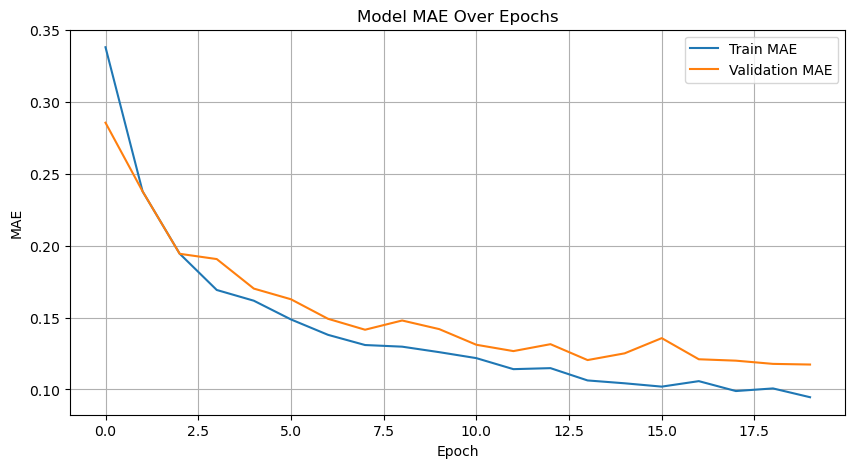

In [19]:
import matplotlib.pyplot as plt

# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# MAE plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model MAE Over Epochs')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


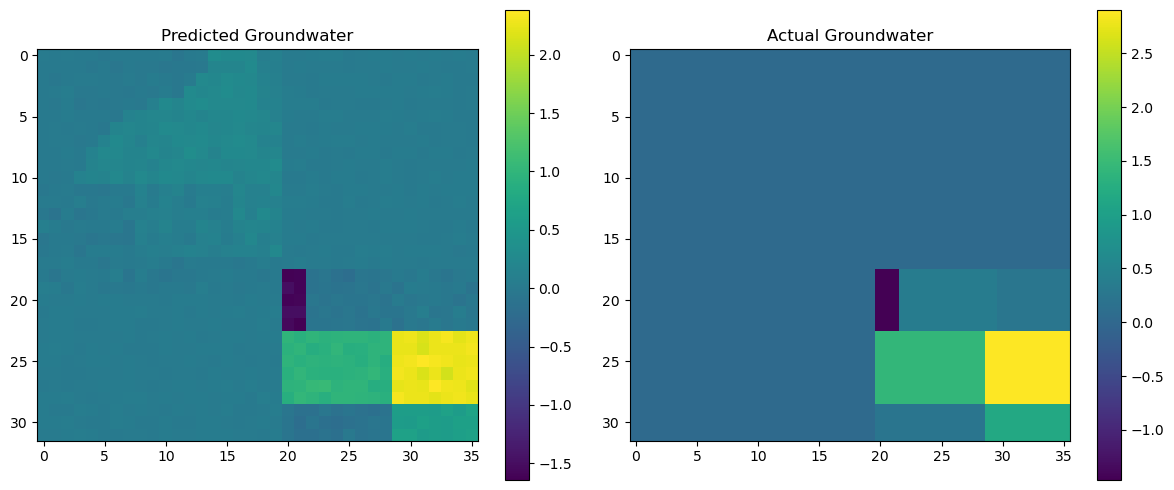

In [23]:
import numpy as np
import matplotlib.pyplot as plt

idx = 0

# Get sample
sample_input = X_test[idx:idx+1]

# Predict
prediction = model.predict(sample_input)

# --- FIX SHAPES ---
pred = prediction[0]
actual = y_test[idx]

# Handle possible shapes
pred = np.squeeze(pred)
actual = np.squeeze(actual)

# If flattened (1024), reshape
if pred.ndim == 1:
    pred = pred.reshape(32, 32)
if actual.ndim == 1:
    actual = actual.reshape(32, 32)

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(pred)
plt.title("Predicted Groundwater")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(actual)
plt.title("Actual Groundwater")
plt.colorbar()

plt.tight_layout()
plt.show()

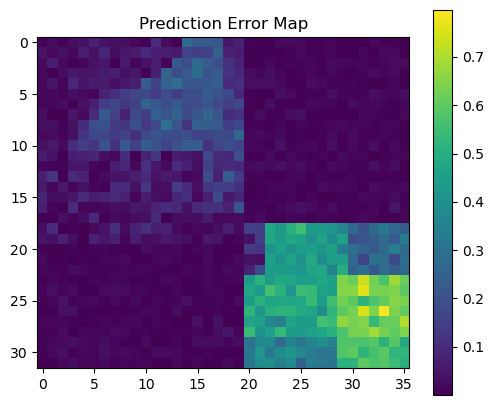

In [24]:
error = np.abs(pred - actual)

plt.figure(figsize=(6,5))
plt.imshow(error)
plt.title("Prediction Error Map")
plt.colorbar()
plt.show()

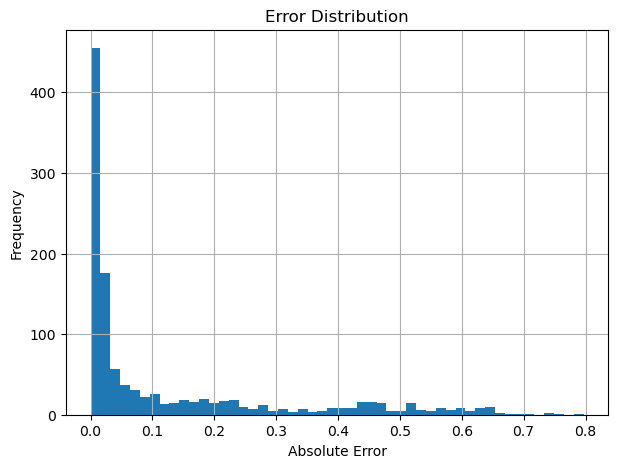

In [25]:
plt.figure(figsize=(7,5))
plt.hist(error.flatten(), bins=50)
plt.title("Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


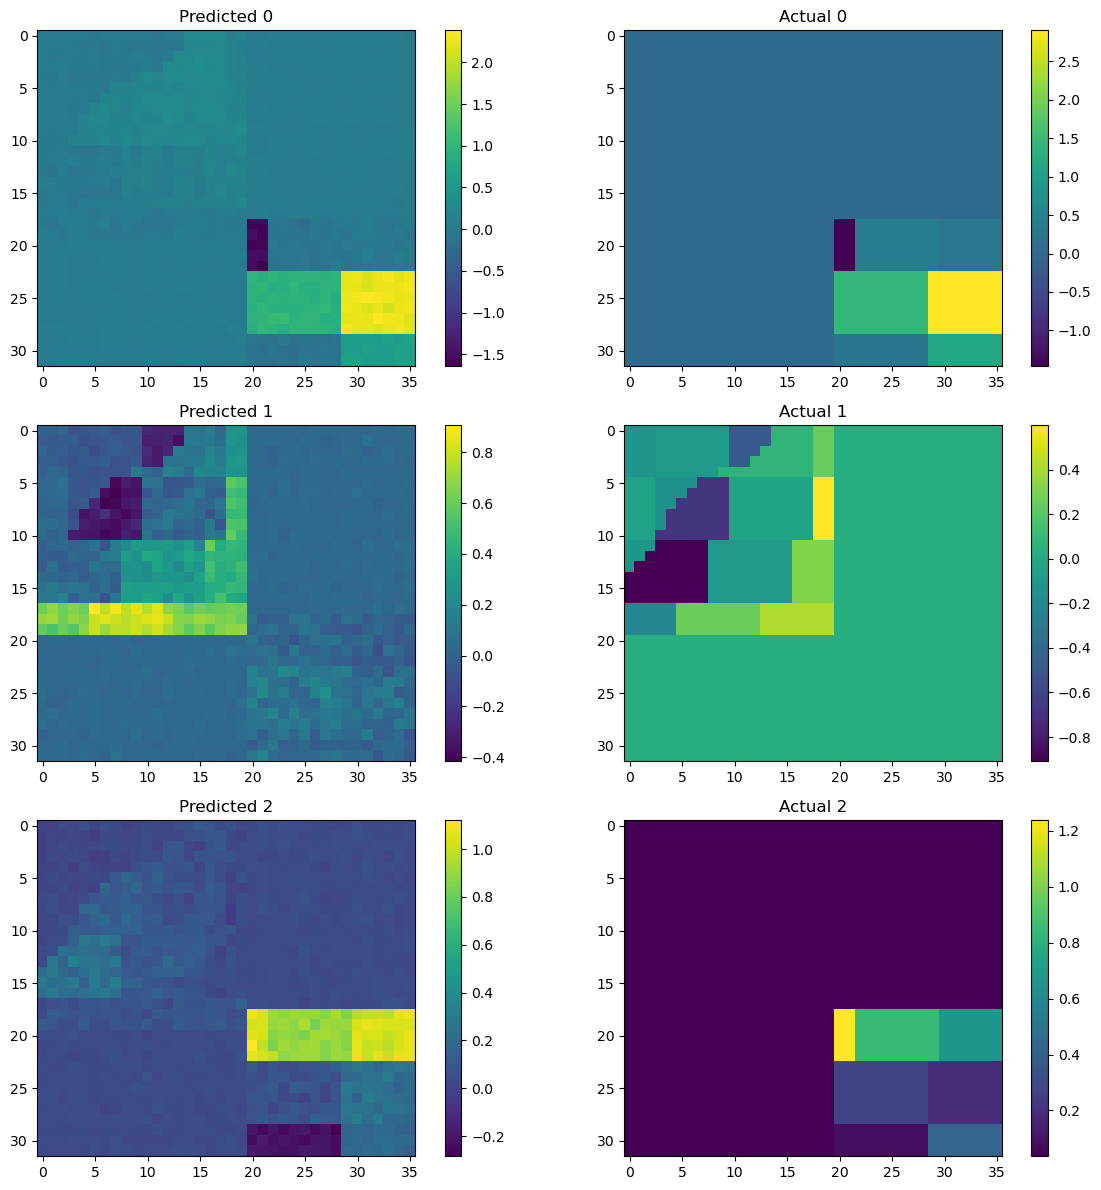

In [26]:
num_samples = 3

plt.figure(figsize=(12, 4 * num_samples))

for i in range(num_samples):
    pred = model.predict(X_test[i:i+1])[0]
    actual = y_test[i]

    pred = np.squeeze(pred)
    actual = np.squeeze(actual)

    if pred.ndim == 1:
        pred = pred.reshape(32, 32)
    if actual.ndim == 1:
        actual = actual.reshape(32, 32)

    plt.subplot(num_samples, 2, 2*i+1)
    plt.imshow(pred)
    plt.title(f"Predicted {i}")
    plt.colorbar()

    plt.subplot(num_samples, 2, 2*i+2)
    plt.imshow(actual)
    plt.title(f"Actual {i}")
    plt.colorbar()

plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = model.predict(X_test)

# Flatten everything safely
y_pred_flat = np.ravel(y_pred)
y_test_flat = np.ravel(y_test)

mse = mean_squared_error(y_test_flat, y_pred_flat)
mae = mean_absolute_error(y_test_flat, y_pred_flat)

print("Final Test MSE:", mse)
print("Final Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
Final Test MSE: 0.0713640944404691
Final Test MAE: 0.11736173194067313
